In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:

import os
import time
import warnings
from datetime import datetime, date
from pathlib import Path

import gymnasium as gym
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gymnasium import spaces
from IPython.display import clear_output
from scipy.special import erfc
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from tqdm import tqdm


In [4]:

class MouseNavigationEnv(gym.Env):
    """
    Mouse Navigation Environment with Left and Right Visual Areas.

    The mouse navigates a 2D arena to find the correct reward port based on
    accumulated left and right visual information, affected by observation noise.
    """

    def __init__(self, noise, info_matrix, nx=60, ny=50, max_v=4, i_threshold=20,
                 vcost=0.01, wcost=0.01, timecost=0.01, info_scale=1 / 20,
                 max_steps=100, reward_magnitude=1):
        super(MouseNavigationEnv, self).__init__()

        # Arena dimensions
        self.nx = nx
        self.ny = ny
        self.max_v = max_v
        self.i_threshold = i_threshold

        # Observation noise (standard deviation)
        self.noise = noise

        # Costs
        self.vcost = vcost
        self.wcost = wcost
        self.timecost = timecost
        self.info_scale = info_scale
        self.reward_magnitude = reward_magnitude

        self.info_matrix = info_matrix

        # Port locations
        self.left_port_x = 0
        self.right_port_x = nx - 1
        self.port_y = ny - 1

        # Correct port will be randomly selected in reset()
        self.correct_port_x = None

        # Maximum steps per episode
        self.max_steps = max_steps

        # Action space: Acceleration in x and y directions [-3, -2, -1, 0, 1, 2, 3]
        self.action_space = spaces.MultiDiscrete([7, 7])

        # Observation space: [x, y, vx, vy, left_info, right_info]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, -1, -1, -1]),
            high=np.array([1, 1, 1, 1, 1]), # normalize
            # high=np.array([nx - 1, ny - 1, max_v, max_v, 1]),
            dtype=np.float32
        )

        # Initialize state
        self.reset()

    def reset(self, seed=None, options=None):
        """Reset the environment to the starting state."""
        super().reset(seed=seed)

        # Start at the bottom center
        self.x = self.nx // 2
        self.y = 0

        # Start with zero velocity
        self.vx = 0
        self.vy = 0

        # Reset accumulated information
        self.cumulative_info = 0

        # Reset step counter
        self.steps = 0

        if options is not None:
            self.correct_port_x = options
        else:
            # Randomly select the correct port (left or right)
            self.correct_port_x = np.random.choice([self.left_port_x, self.right_port_x])

        # Current state
        self._update_state()

        return self.state, {}

    def _update_state(self):
        """Update the state vector."""
        if self.correct_port_x == 0:
            rewardp=self._success_prob_from_info(self.cumulative_info)*2-1
        else:
            rewardp=(self._success_prob_from_info(-self.cumulative_info)*2-1)*-1
        self.state = np.array([
            self.x/(self.nx-1), 
            self.y/(self.ny-1), 
            self.vx/self.max_v, 
            self.vy/self.max_v,
            rewardp
        ], dtype=np.float32)

    def _get_area_info_at_position(self, x, y, testing=False):
        """Get left and right area information at the given position with noise."""
        # Convert to integer indices and clip to bounds
        x_idx = max(0, min(int(x), self.nx - 1))
        y_idx = max(0, min(int(y), self.ny - 1))

        # Get raw values from matrices
        raw = self.info_matrix[x_idx, y_idx] * self.info_scale

        # Add observation noise. the noisy can be no info at all, or can by no noise (full info at the location)
        # we want: less info more chance to not observe anyything
        # noisy = (raw - np.max(self.info_matrix)/3*self.noise*(np.random.uniform(0, 1)))
        p=raw/np.max(self.info_matrix)
        noisy=(p-np.random.uniform(0, 1*self.noise))
        noisy = max(0, noisy)

        if testing:
            noisy = raw
        if self.correct_port_x == 0:
            return noisy
        else:
            return -noisy

    def _success_prob_from_info(self, info_val):
        """
        Calculate success probability based on accumulated left and right information.
        Higher difference between the correct choice and incorrect choice
        leads to higher success probability.
        """

        info_val = abs(info_val)

        # Use the erfc function: (1/2) * erfc(-sqrt(J/2))
        return 0.5 * erfc(-np.sqrt(info_val / 2))

    def step(self, action, testing=False):
        """
        Take a step in the environment based on the action.

        Args:
            action: [ax, ay] representing accelerations in x and y directions
                   Each element is in range [0, 6] which maps to [-3, -2, -1, 0, 1, 2, 3]

        Returns:
            (state, reward, done, truncated, info)
        """
        reward=0

        # Increment step counter
        self.steps += 1

        # Map action to acceleration
        ax = action[0]-3
        ay = action[1]-3
        # print(ax,ay)
        # Calculate next velocity
        next_vx = self.vx + ax
        next_vy = self.vy + ay
        # print(next_vx,next_vy)
        # Check velocity constraints
        speed = np.sqrt(next_vx**2 + next_vy**2)
        if speed >= self.max_v:
            # Scale down the velocity to max_v
            scaling_factor = (self.max_v - 0.1) / speed
            next_vx = next_vx * scaling_factor
            next_vy = next_vy * scaling_factor

        # Store old position for reward calculation
        old_x, old_y = self.x, self.y

        # Update position
        self.x += next_vx
        self.y += next_vy

        # wall penalty
        wall_penalty = 0
        # original_x, original_y = self.x, self.y

        # Check if hitting walls and apply penalty
        if self.x < 0 or self.x >= self.nx:
            wall_penalty -= 0  # Adjust penalty amount as needed
        if self.y < 0 or self.y >= self.ny:
            wall_penalty -= 0
        reward += wall_penalty


        # Clip position to arena boundaries
        self.x = max(0, min(self.x, self.nx - 1))
        self.y = max(0, min(self.y, self.ny - 1))

        # Check if approaching a port and enforce horizontal approach
        approaching_port = (self.y >= self.port_y - abs(next_vy) and
                            (abs(self.x - self.left_port_x) <= abs(next_vx) or
                            abs(self.x - self.right_port_x) <= abs(next_vx)))

        if approaching_port:
            # Force horizontal approach by zeroing out vertical velocity
            self.vy = 0
        else:
            self.vy = next_vy

        self.vx = next_vx

        # Accumulate left and right information at current position
        info_gain = self._get_area_info_at_position(old_x, old_y, testing)
        self.cumulative_info += info_gain

        # Calculate costs
        velocity_cost = np.sqrt(self.vx**2 + self.vy**2) * self.vcost
        accel_cost = np.sqrt(ax**2 + ay**2) * self.wcost
        step_cost = -velocity_cost - accel_cost - self.timecost

        # Check if done
        at_left_port = (round(self.y) == self.port_y and round(self.x) == self.left_port_x)
        at_right_port = (round(self.y) == self.port_y and round(self.x) == self.right_port_x)
        at_port = at_left_port or at_right_port

        stopped = (abs(self.vx) < 0.01 and abs(self.vy) < 0.01 and self.steps > 1)
        reached_steps_limit = self.steps >= self.max_steps

        done = at_port or stopped or reached_steps_limit

        # Calculate reward
        reward += step_cost  # Always apply movement costs
        success_prob = self._success_prob_from_info(self.cumulative_info)
        if at_port:
            # Calculate success probability based on accumulated information
            

            # Check if the mouse chose the correct port
            correct_choice = ((at_left_port and self.correct_port_x == self.left_port_x) or
                              (at_right_port and self.correct_port_x == self.right_port_x))

            # Stochastically determine success based on accumulated information
            if correct_choice:
                # Success with probability based on accumulated info
                reward_outcome = success_prob * self.reward_magnitude
            else:
                # Failure with probability based on accumulated info (incorrect choice)
                # reward_outcome = 1 - success_prob*self.reward_magnitude
                reward_outcome = -success_prob * self.reward_magnitude*5

            reward += reward_outcome
        elif stopped:
            # Penalty for stopping without reaching a port
            reward -= 0.5 * self.reward_magnitude
        elif reached_steps_limit:
            # Small penalty for timeout
            reward -= 0.25 * self.reward_magnitude

        # if know which port, reward for going toward it
        # if success_prob>0.3:
        #     # print(success_prob, self.vx, np.sign(self.cumulative_info), success_prob*self.vx*np.sign(self.cumulative_info)*-1)
        #     away_punish=success_prob*self.vx*np.sign(self.cumulative_info)*-1*0.05
        #     reward+=min(0,away_punish)

        # Update state
        self._update_state()

        # Info dictionary for additional data
        info = {
            'position': (self.x, self.y),
            'velocity': (self.vx, self.vy),
            'cumulative_info': self.cumulative_info,
            'step_cost': step_cost,
            'at_port': at_port,
            'correct_port': 'left' if self.correct_port_x == self.left_port_x else 'right',
            'chosen_port': 'left' if at_left_port else ('right' if at_right_port else None),
            'success_prob': self._success_prob_from_info(
                self.cumulative_info
            ),
            'info_gain': info_gain,
        }

        return self.state, reward, done, False, info



In [5]:
def compare_models_multi_gaps(models, envs, info_matrices, gaps, 
                             trials_per_condition=30, 
                             colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
                             save_path=None, 
                             figure_title='Multi-Gap Model Comparison - Average Trajectories'):
    """
    Compare multiple models across different gap widths with trajectory visualization.
    
    Parameters:
    - models: List of trained models for each gap
    - envs: List of environments for each gap
    - info_matrices: List of information matrices for each gap
    - gaps: Array of gap widths
    - trials_per_condition: Number of trials to run for each condition (left/right)
    - colors_multi_aperture: Colors for each gap width
    - save_path: Optional path to save the figure
    - figure_title: Title for the figure
    """
    import warnings
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    
    # Function to interpolate trajectories
    def interpolate_trajectory(x, y, n_points):
        """Interpolate trajectory to fixed number of points"""
        from scipy.interpolate import interp1d
        if len(x) < 2:
            return np.array([x[0]] * n_points), np.array([y[0]] * n_points)
        
        t_orig = np.linspace(0, 1, len(x))
        t_new = np.linspace(0, 1, n_points)
        
        fx = interp1d(t_orig, x, kind='linear')
        fy = interp1d(t_orig, y, kind='linear')
        
        return fx(t_new), fy(t_new)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Store all model data for statistics
    all_model_data = []
    legend_handles = []
    legend_labels = []
    
    # Line styles for different gaps (cycle through if more gaps than styles)
    line_styles = ['-']*5
    
    # Process each gap/model combination
    for i, (model, env, gap) in enumerate(zip(models, envs, gaps)):
        if model is None:
            print(f"Skipping gap {gap} - model not loaded")
            continue
            
        print(f"Running trials for gap width {gap}...")
        
        # Run trials for this model
        model_data = run_model_trials(model, env, trials_per_condition)
        all_model_data.append((model_data, gap))
        
        # Use the same color for both left and right trajectories of this gap
        gap_color = colors_multi_aperture[i % len(colors_multi_aperture)]
        colors_choice = [gap_color, gap_color]  # Same color for left/right
        linestyle = line_styles[i % len(line_styles)]
        
        # Plot trajectories for this gap
        plot_model_trajectories_multi_gap(
            model_data, colors_choice, alpha=0.3, linewidth=0.8, 
            linestyle=linestyle, interpolate_trajectory=interpolate_trajectory,
            gap_width=gap, gap_color=gap_color
        )
        
        # Add to legend (one entry per gap)
        legend_handles.append(Line2D([0], [0], color=gap_color, linewidth=2, linestyle=linestyle))
        gap_percentages = [1, 28, 65, 90, 100]  # Add this mapping
        legend_labels.append(f'{gap_percentages[i]}%')
    
    # Create legend
    plt.legend(legend_handles, legend_labels, loc='upper right')
    
    # Styling
    plt.xlabel('x position (cm)')
    plt.ylabel('y position (cm)')
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    plt.xticks([])
    plt.yticks([])
    
    # Add scale bar
    x0, y0 = -15, -5
    ax.plot([x0, x0 + 10], [y0, y0], color='black', lw=1.5)  # horizontal bar (10 cm)
    ax.plot([x0, x0], [y0, y0 + 5], color='black', lw=1.5)   # vertical bar (5 cm)
    
    # Add text labels
    ax.text(x0 + 5, y0 - 0.8, '10 cm', ha='center', va='top', fontsize=8)
    ax.text(x0 - 0.8, y0 + 2.5, '5 cm', ha='right', va='center', fontsize=8, rotation='vertical')
    
    ax.set_title(figure_title)
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, format='svg', bbox_inches='tight')
    
    plt.show()
    
    # Print summary statistics
    print_multi_gap_comparison_stats(all_model_data)


def plot_model_trajectories_multi_gap(model_data, colors_choice, alpha=0.3, linewidth=0.8, 
                                     linestyle='-', interpolate_trajectory=None, 
                                     gap_width=None, gap_color=None):
    """Plot trajectories for a single model/gap with consistent styling"""
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Interpolate trajectories
    left_interp_x, left_interp_y = [], []
    for x, y in zip(model_data['left_positions_x'], model_data['left_positions_y']):
        interp_x, interp_y = interpolate_trajectory(x, y, 100)
        left_interp_x.append(interp_x)
        left_interp_y.append(interp_y)
    
    right_interp_x, right_interp_y = [], []
    for x, y in zip(model_data['right_positions_x'], model_data['right_positions_y']):
        interp_x, interp_y = interpolate_trajectory(x, y, 100)
        right_interp_x.append(interp_x)
        right_interp_y.append(interp_y)
    
    # Calculate means and stds
    left_x_array = np.array(left_interp_x)
    left_y_array = np.array(left_interp_y)
    left_mean_x = np.mean(left_x_array, axis=0)
    left_std_x = np.std(left_x_array, axis=0)
    left_mean_y = np.mean(left_y_array, axis=0)
    left_std_y = np.std(left_y_array, axis=0)
    
    right_x_array = np.array(right_interp_x)
    right_y_array = np.array(right_interp_y)
    right_mean_x = np.mean(right_x_array, axis=0)
    right_std_x = np.std(right_x_array, axis=0)
    right_mean_y = np.mean(right_y_array, axis=0)
    right_std_y = np.std(right_y_array, axis=0)
    
    # # Plot individual trajectories (lighter)
    # for positions_x, positions_y in zip(model_data['left_positions_x'], model_data['left_positions_y']):
    #     plt.plot(positions_x, positions_y, color=gap_color, alpha=alpha*0.6, 
    #             linewidth=linewidth*0.7, linestyle=linestyle)
    
    # for positions_x, positions_y in zip(model_data['right_positions_x'], model_data['right_positions_y']):
    #     plt.plot(positions_x, positions_y, color=gap_color, alpha=alpha*0.6, 
    #             linewidth=linewidth*0.7, linestyle=linestyle)
    
    # Plot mean trajectories (thicker, more opaque)
    plt.plot(left_mean_x, left_mean_y, color=gap_color, linewidth=2.5, 
            linestyle=linestyle, alpha=0.9)
    plt.plot(right_mean_x, right_mean_y, color=gap_color, linewidth=2.5, 
            linestyle=linestyle, alpha=0.9)
    
    # Add error bands (lighter)
    plt.fill_between(left_mean_x, 
                    left_mean_y - left_std_y, 
                    left_mean_y + left_std_y, 
                    alpha=0.15, color=gap_color)
    plt.fill_between(right_mean_x, 
                    right_mean_y - right_std_y, 
                    right_mean_y + right_std_y, 
                    alpha=0.15, color=gap_color)


def run_model_trials(model, env, trials_per_condition):
    """Run trials for a single model and return trajectory data"""
    import warnings
    import numpy as np
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Storage for trial data
        left_trial_positions_x = []
        left_trial_positions_y = []
        left_trial_results = []
        left_trial_rewards = []
        
        right_trial_positions_x = []
        right_trial_positions_y = []
        right_trial_results = []
        right_trial_rewards = []
        
        # Run left port trials
        for trial in range(trials_per_condition):
            obs, _ = env.reset(options=0)
            done = False
            positions_x = []
            positions_y = []
            total_reward = 0
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _, info = env.step(action)
                total_reward += reward
                
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
            
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            left_trial_positions_x.append(positions_x)
            left_trial_positions_y.append(positions_y)
            left_trial_rewards.append(total_reward)
            
            result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
            if info['chosen_port'] is None:
                result = "Timeout/Stopped"
            left_trial_results.append(result)
        
        # Run right port trials
        for trial in range(trials_per_condition):
            obs, _ = env.reset(options=59)
            done = False
            positions_x = []
            positions_y = []
            total_reward = 0
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _, info = env.step(action)
                total_reward += reward
                
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
            
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            right_trial_positions_x.append(positions_x)
            right_trial_positions_y.append(positions_y)
            right_trial_rewards.append(total_reward)
            
            result = "Success" if info['chosen_port'] == info['correct_port'] else "Failure"
            if info['chosen_port'] is None:
                result = "Timeout/Stopped"
            right_trial_results.append(result)
    
    return {
        'left_positions_x': left_trial_positions_x,
        'left_positions_y': left_trial_positions_y,
        'left_results': left_trial_results,
        'left_rewards': left_trial_rewards,
        'right_positions_x': right_trial_positions_x,
        'right_positions_y': right_trial_positions_y,
        'right_results': right_trial_results,
        'right_rewards': right_trial_rewards
    }


def print_multi_gap_comparison_stats(all_model_data):
    """Print comparison statistics between multiple gap models"""
    import numpy as np
    
    print(f"\n=== Multi-Gap Model Comparison Statistics ===")
    
    for model_data, gap in all_model_data:
        # Calculate success rates
        left_success = sum(1 for r in model_data['left_results'] if r == "Success") / len(model_data['left_results'])
        right_success = sum(1 for r in model_data['right_results'] if r == "Success") / len(model_data['right_results'])
        overall_success = (left_success + right_success) / 2
        
        print(f"Gap {gap}:")
        print(f"  Left trials: Success Rate = {left_success:.2f}, Avg Reward = {np.mean(model_data['left_rewards']):.2f}")
        print(f"  Right trials: Success Rate = {right_success:.2f}, Avg Reward = {np.mean(model_data['right_rewards']):.2f}")
        print(f"  Overall Success Rate = {overall_success:.2f}")
        print()



Final testing for epoch 15
Gap widths: [ 6  8 10 12 14]
Setup environment for gap 6
Setup environment for gap 8
Setup environment for gap 10
Setup environment for gap 12
Setup environment for gap 14
✓ Loaded model for gap width 6 from ./final_mouse_navigation_modelw6
✓ Loaded model for gap width 8 from ./final_mouse_navigation_modelw8
✓ Loaded model for gap width 10 from ./final_mouse_navigation_modelw10
✓ Loaded model for gap width 12 from ./final_mouse_navigation_modelw12
✓ Loaded model for gap width 14 from ./final_mouse_navigation_modelw14
Successfully loaded 5/5 models
Comparing 5 models...
Running trials for gap width 6...
Running trials for gap width 8...
Running trials for gap width 10...
Running trials for gap width 12...
Running trials for gap width 14...


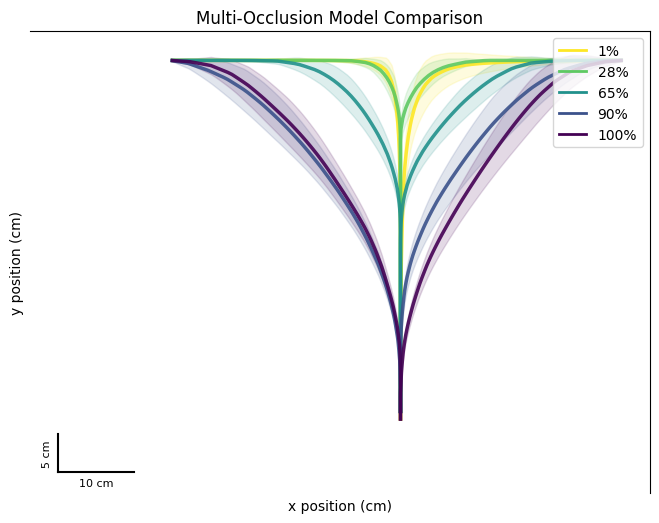


=== Multi-Gap Model Comparison Statistics ===
Gap 6:
  Left trials: Success Rate = 1.00, Avg Reward = 1.36
  Right trials: Success Rate = 1.00, Avg Reward = 1.23
  Overall Success Rate = 1.00

Gap 8:
  Left trials: Success Rate = 1.00, Avg Reward = 1.58
  Right trials: Success Rate = 1.00, Avg Reward = 1.55
  Overall Success Rate = 1.00

Gap 10:
  Left trials: Success Rate = 1.00, Avg Reward = 1.66
  Right trials: Success Rate = 1.00, Avg Reward = 1.66
  Overall Success Rate = 1.00

Gap 12:
  Left trials: Success Rate = 1.00, Avg Reward = 1.67
  Right trials: Success Rate = 1.00, Avg Reward = 1.70
  Overall Success Rate = 1.00

Gap 14:
  Left trials: Success Rate = 1.00, Avg Reward = 1.77
  Right trials: Success Rate = 1.00, Avg Reward = 1.73
  Overall Success Rate = 1.00



In [6]:

# Define parameters
epoch = 14
gaps = np.linspace(6, 14, 5).astype(int)  # [6, 8, 10, 12, 14]
colors_multi_aperture = ["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"]

print(f"Final testing for epoch {epoch + 1}")
print(f"Gap widths: {gaps}")

# Setup environments and info matrices (needed for testing)
envs = []
info_matrices = []

for gap in gaps:
    # Load and process info matrix
    info_matrix = np.load(f'new_info_matrix_hres_{gap}.npy')[:,:-10]
    info_matrices.append(info_matrix)
    
    # Create mask (mimic animal cannot see well)
    mask = np.ones_like(info_matrix)
    gradient = np.linspace(0.0, 1., info_matrix.shape[1])
    for i in range(info_matrix.shape[1]):
        mask[:, i] = gradient[i]
    
    # Apply the mask to darken the bottom gradually
    masked_info_matrix = info_matrix * mask
    
    # Create environment
    env = MouseNavigationEnv(
        info_matrix=info_matrix,
        nx=60, ny=50, max_v=4, i_threshold=5, 
        noise=0.3, 
        vcost=0.01, 
        wcost=0.01, 
        timecost=0.001, 
        info_scale=0.3,
        max_steps=200, 
        reward_magnitude=3
    )
    envs.append(env)
    print(f"Setup environment for gap {gap}")

# Load trained models for each gap width
models = []
for gap in gaps:
    model_path = f"./final_mouse_navigation_modelw{gap}"  # Updated to match your training script naming
    try:
        model = PPO.load(model_path)
        models.append(model)
        print(f"✓ Loaded model for gap width {gap} from {model_path}")
    except Exception as e:
        print(f"✗ Warning: Could not load model for gap width {gap}: {e}")
        models.append(None)

# Check if we have any valid models
valid_models = [m for m in models if m is not None]
valid_gaps = [gap for gap, model in zip(gaps, models) if model is not None]
valid_envs = [env for env, model in zip(envs, models) if model is not None]
valid_info_matrices = [info for info, model in zip(info_matrices, models) if model is not None]
valid_colors = [colors_multi_aperture[i] for i, model in enumerate(models) if model is not None]

if len(valid_models) == 0:
    print("ERROR: No models could be loaded! Check your model paths.")
else:
    print(f"Successfully loaded {len(valid_models)}/{len(gaps)} models")
    
    # Compare all valid models
    print(f"Comparing {len(valid_models)} models...")
    compare_models_multi_gaps(
        models=valid_models,
        envs=valid_envs, 
        info_matrices=valid_info_matrices,
        gaps=valid_gaps,
        trials_per_condition=100,
        colors_multi_aperture=valid_colors,
        save_path=f"final_multi_gap_comparison_epoch.svg",
        figure_title=f"Multi-Occlusion Model Comparison"
    )
    


Running velocity analysis for gap width 6...
Running velocity analysis for gap width 8...
Running velocity analysis for gap width 10...
Running velocity analysis for gap width 12...
Running velocity analysis for gap width 14...


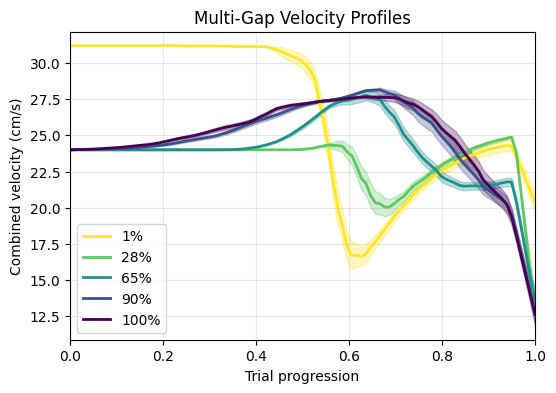


=== Multi-Gap Velocity Statistics ===
Gap 6:
  Mean velocity: 26.54 ± 0.08 cm/s (SEM)
  Standard deviation: 6.06 cm/s
  Max velocity: 31.20 cm/s
  Min velocity: 1.60 cm/s

Gap 8:
  Mean velocity: 23.25 ± 0.04 cm/s (SEM)
  Standard deviation: 2.91 cm/s
  Max velocity: 28.72 cm/s
  Min velocity: 4.44 cm/s

Gap 10:
  Mean velocity: 23.95 ± 0.04 cm/s (SEM)
  Standard deviation: 3.06 cm/s
  Max velocity: 28.72 cm/s
  Min velocity: 4.57 cm/s

Gap 12:
  Mean velocity: 24.72 ± 0.05 cm/s (SEM)
  Standard deviation: 3.77 cm/s
  Max velocity: 28.72 cm/s
  Min velocity: 4.54 cm/s

Gap 14:
  Mean velocity: 24.88 ± 0.05 cm/s (SEM)
  Standard deviation: 3.86 cm/s
  Max velocity: 28.72 cm/s
  Min velocity: 3.58 cm/s



In [10]:
def analyze_velocity_multi_gaps(models, envs, info_matrices, gaps, 
                               trials_per_condition=30, 
                               colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
                               save_path=None, 
                               figure_title='Multi-Gap Velocity Comparison'):
    """
    Analyze and plot velocity profiles for multiple models across different gap widths.
    Now uses SEM (Standard Error of the Mean) instead of STD.
    """
    import warnings
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from scipy.stats import sem
    
    gap_percentages = [1, 28, 65, 90, 100]
    # Create figure
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Store velocity data for all gaps
    all_gap_velocities = []
    gap_labels = []
    gap_colors = []
    
    # Process each gap/model combination
    for i, (model, env, gap) in enumerate(zip(models, envs, gaps)):
        if model is None:
            print(f"Skipping gap {gap} - model not loaded")
            continue
            
        print(f"Running velocity analysis for gap width {gap}...")
        
        # Collect trajectory data
        velocity_data = run_velocity_trials_improved(model, env, trials_per_condition)
        
        # Process velocities similar to your code style
        left_velocities = []
        right_velocities = []
        
        # Process left trials
        for x, y in zip(velocity_data['left_positions_x'], velocity_data['left_positions_y']):
            vel = compute_velocity(x, y)
            if len(vel) > 1:
                progress = np.linspace(0, 1, len(vel))
                common_progress = np.linspace(0, 1, 100)
                interp_vel = np.interp(common_progress, progress, vel)
                left_velocities.append(interp_vel)
        
        # Process right trials
        for x, y in zip(velocity_data['right_positions_x'], velocity_data['right_positions_y']):
            vel = compute_velocity(x, y)
            if len(vel) > 1:
                progress = np.linspace(0, 1, len(vel))
                common_progress = np.linspace(0, 1, 100)
                interp_vel = np.interp(common_progress, progress, vel)
                right_velocities.append(interp_vel)
        
        # Combine left and right velocities
        if left_velocities and right_velocities:
            left_vel_array = np.array(left_velocities)
            right_vel_array = np.array(right_velocities)
            combined_vel = np.concatenate([left_vel_array, right_vel_array])
            
            # Store for this gap
            all_gap_velocities.append(combined_vel)
            gap_labels.append(f'{gap_percentages[i]}%')
            gap_colors.append(colors_multi_aperture[i % len(colors_multi_aperture)])
    
    # Plot all gaps
    progress = np.linspace(0, 1, 100)
    
    for i, (velocities, label, color) in enumerate(zip(all_gap_velocities, gap_labels, gap_colors)):
        mean_vel = np.mean(velocities, axis=0)
        sem_vel = sem(velocities, axis=0)  # Changed from std to sem
        
        # Plot mean line
        plt.plot(progress, mean_vel, color=color, linewidth=2, label=label)
        
        # Plot error band (now using SEM)
        plt.fill_between(progress, 
                        mean_vel - sem_vel, 
                        mean_vel + sem_vel, 
                        alpha=0.3, color=color)
    
    # Styling
    plt.xlabel('Trial progression')
    plt.ylabel('Combined velocity (cm/s)')
    plt.title(figure_title)
    plt.legend()
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.3)
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, format='svg', bbox_inches='tight')
    
    plt.show()
    
    # Print velocity statistics
    print_velocity_stats_improved(all_gap_velocities, gaps)


def run_velocity_trials_improved(model, env, trials_per_condition):
    """Run trials and collect position data for velocity analysis"""
    import warnings
    import numpy as np
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Storage for position data
        left_trial_positions_x = []
        left_trial_positions_y = []
        right_trial_positions_x = []
        right_trial_positions_y = []
        
        # Run left port trials
        for trial in range(trials_per_condition):
            obs, _ = env.reset(options=0)
            done = False
            positions_x = []
            positions_y = []
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _, info = env.step(action)
                
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
            
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            left_trial_positions_x.append(positions_x)
            left_trial_positions_y.append(positions_y)
        
        # Run right port trials
        for trial in range(trials_per_condition):
            obs, _ = env.reset(options=59)
            done = False
            positions_x = []
            positions_y = []
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _, info = env.step(action)
                
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
            
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            right_trial_positions_x.append(positions_x)
            right_trial_positions_y.append(positions_y)
    
    return {
        'left_positions_x': left_trial_positions_x,
        'left_positions_y': left_trial_positions_y,
        'right_positions_x': right_trial_positions_x,
        'right_positions_y': right_trial_positions_y
    }


def compute_velocity(positions_x, positions_y, dt=0.1):
    """Compute velocity from position data"""
    # Scale to cm: x from [0,59] to [-20,20], y from [0,49] to [-20,20]
    x_cm = (positions_x / 60) * 40 - 20  # maps [0,59] to [-20,20]
    y_cm = (positions_y / 50) * 40 - 20  # maps [0,49] to [-20,20]
    
    dx = np.diff(x_cm)
    dy = np.diff(y_cm)
    velocity = np.sqrt(dx**2 + dy**2) / dt
    return velocity


def interpolate_velocity_trajectory(velocities, n_points):
    """Interpolate velocity trajectory to fixed number of points"""
    import numpy as np
    from scipy.interpolate import interp1d
    
    if len(velocities) < 2:
        return np.array([velocities[0]] * n_points if len(velocities) > 0 else [0.0] * n_points)
    
    t_orig = np.linspace(0, 1, len(velocities))
    t_new = np.linspace(0, 1, n_points)
    
    f_vel = interp1d(t_orig, velocities, kind='linear')
    
    return f_vel(t_new)


def plot_velocity_profiles(velocity_data, gap_color, alpha=0.3, linewidth=0.8, 
                          linestyle='-', gap_width=None, dt=0.1):
    """Plot velocity profiles for a single gap condition (now uses SEM)"""
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import sem
    
    # Combine left and right velocities
    all_velocities = velocity_data['left_velocities'] + velocity_data['right_velocities']
    
    if not all_velocities:
        return
    
    # Interpolate all velocity trajectories to same length
    max_length = 100  # Standard length for comparison
    interpolated_velocities = []
    
    for velocities in all_velocities:
        if len(velocities) > 0:
            interp_vel = interpolate_velocity_trajectory(velocities, max_length)
            interpolated_velocities.append(interp_vel)
    
    if not interpolated_velocities:
        return
    
    # Convert to array and calculate statistics
    vel_array = np.array(interpolated_velocities)
    mean_velocity = np.mean(vel_array, axis=0)
    sem_velocity = sem(vel_array, axis=0)  # Changed from std to sem
    
    # Create time axis
    time_axis = np.linspace(0, max_length * dt / 10, max_length)  # Approximate time scaling
    
    # Plot individual velocity profiles (lighter)
    for velocities in all_velocities[:10]:  # Plot only first 10 for clarity
        if len(velocities) > 1:
            time_individual = np.arange(len(velocities)) * dt
            plt.plot(time_individual, velocities, color=gap_color, alpha=alpha*0.5, 
                    linewidth=linewidth*0.5, linestyle=linestyle)
    
    # Plot mean velocity profile (thicker)
    plt.plot(time_axis, mean_velocity, color=gap_color, linewidth=2.5, 
            linestyle=linestyle, alpha=0.9)
    
    # Add error band (now using SEM)
    plt.fill_between(time_axis, 
                    mean_velocity - sem_velocity, 
                    mean_velocity + sem_velocity, 
                    alpha=0.15, color=gap_color)


def print_velocity_stats_improved(all_gap_velocities, gaps):
    """Print velocity statistics for all gaps (now includes SEM)"""
    import numpy as np
    from scipy.stats import sem
    
    print(f"\n=== Multi-Gap Velocity Statistics ===")
    
    for i, (velocities, gap) in enumerate(zip(all_gap_velocities, gaps)):
        # Flatten all velocity data for this gap
        flat_velocities = velocities.flatten()
        
        # Calculate statistics
        mean_vel = np.mean(flat_velocities)
        std_vel = np.std(flat_velocities)
        sem_vel = sem(flat_velocities)  # Added SEM calculation
        max_vel = np.max(flat_velocities)
        min_vel = np.min(flat_velocities)
        
        print(f"Gap {gap}:")
        print(f"  Mean velocity: {mean_vel:.2f} ± {sem_vel:.2f} cm/s (SEM)")
        print(f"  Standard deviation: {std_vel:.2f} cm/s")
        print(f"  Max velocity: {max_vel:.2f} cm/s")
        print(f"  Min velocity: {min_vel:.2f} cm/s")
        print()


def analyze_velocity_by_phase_multi_gaps_improved(models, envs, info_matrices, gaps, 
                                                 trials_per_condition=30, 
                                                 colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
                                                 save_path=None):
    """
    Analyze velocity in different phases: initial, middle, final thirds of trajectory
    Now uses SEM instead of STD for error bars.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import sem
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    phases = ['Initial', 'Middle', 'Final']
    axes = [ax1, ax2, ax3]
    
    gap_phase_data = {}
    
    for i, (model, env, gap) in enumerate(zip(models, envs, gaps)):
        if model is None:
            continue
            
        print(f"Running phase analysis for gap width {gap}...")
        
        # Collect trajectory data
        trajectory_data = run_velocity_trials_improved(model, env, trials_per_condition)
        
        # Combine left and right positions
        all_positions_x = trajectory_data['left_positions_x'] + trajectory_data['right_positions_x']
        all_positions_y = trajectory_data['left_positions_y'] + trajectory_data['right_positions_y']
        
        # Analyze velocity in three phases
        phase_velocities = [[], [], []]  # initial, middle, final
        
        for x, y in zip(all_positions_x, all_positions_y):
            vel = compute_velocity(x, y)
            if len(vel) >= 3:
                third = len(vel) // 3
                phase_velocities[0].extend(vel[:third])           # Initial
                phase_velocities[1].extend(vel[third:2*third])   # Middle  
                phase_velocities[2].extend(vel[2*third:])        # Final
        
        gap_phase_data[gap] = phase_velocities
    
    # Plot phase comparisons
    for phase_idx, (ax, phase_name) in enumerate(zip(axes, phases)):
        gap_means = []
        gap_sems = []  # Changed from gap_stds to gap_sems
        gap_labels = []
        gap_colors = []
        
        for i, gap in enumerate(gaps):
            if gap in gap_phase_data and gap_phase_data[gap][phase_idx]:
                phase_vel = np.array(gap_phase_data[gap][phase_idx])
                gap_means.append(np.mean(phase_vel))
                gap_sems.append(sem(phase_vel))  # Changed from std to sem
                gap_labels.append(f'Gap {gap}')
                gap_colors.append(colors_multi_aperture[i % len(colors_multi_aperture)])
        
        # Bar plot with error bars (now using SEM)
        x_pos = np.arange(len(gap_labels))
        bars = ax.bar(x_pos, gap_means, yerr=gap_sems, capsize=5, 
                     color=gap_colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        
        ax.set_xlabel('Gap Width')
        ax.set_ylabel('Velocity (cm/s)')
        ax.set_title(f'{phase_name} Phase')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(gap_labels)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Velocity by Trial Phase (Error bars: SEM)')
    plt.tight_layout()
    
    if save_path:
        phase_save_path = save_path.replace('.svg', '_phases.svg')
        plt.savefig(phase_save_path, format='svg', bbox_inches='tight')
    
    plt.show()


# Usage example:
"""
# Run velocity analysis with improved data handling
analyze_velocity_multi_gaps(
    models=models,
    envs=envs, 
    info_matrices=info_matrices,
    gaps=gaps,
    trials_per_condition=30,
    colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
    save_path="velocity_comparison.svg",
    figure_title="Multi-Gap Velocity Profiles"
)

# Run phase-based velocity analysis
analyze_velocity_by_phase_multi_gaps_improved(
    models=models,
    envs=envs, 
    info_matrices=info_matrices,
    gaps=gaps,
    trials_per_condition=30,
    colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
    save_path="velocity_phases.svg"
)
"""
analyze_velocity_multi_gaps(
    models=models,
    envs=envs, 
    info_matrices=info_matrices,
    gaps=gaps,
    trials_per_condition=30,
    colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
    save_path="velocity_comparison.svg",
    figure_title="Multi-Gap Velocity Profiles")

Running acceleration analysis for gap width 6...
Running acceleration analysis for gap width 8...
Running acceleration analysis for gap width 10...
Running acceleration analysis for gap width 12...
Running acceleration analysis for gap width 14...


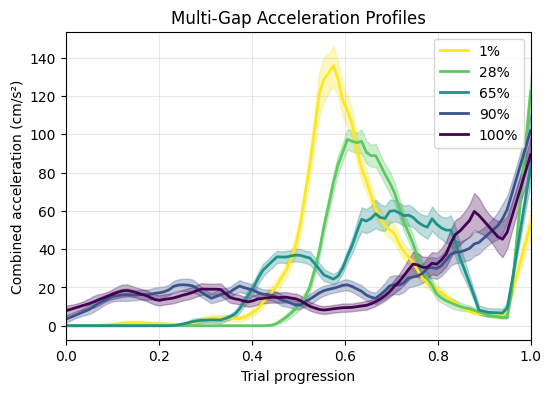


=== Multi-Gap Acceleration Statistics ===
Gap 6:
  Mean acceleration: 27.32 ± 0.62 cm/s² (SEM)
  Standard deviation: 48.35 cm/s²
  Max acceleration: 289.05 cm/s²
  Min acceleration: 0.00 cm/s²

Gap 8:
  Mean acceleration: 22.75 ± 0.52 cm/s² (SEM)
  Standard deviation: 40.18 cm/s²
  Max acceleration: 209.34 cm/s²
  Min acceleration: 0.00 cm/s²

Gap 10:
  Mean acceleration: 23.90 ± 0.47 cm/s² (SEM)
  Standard deviation: 36.25 cm/s²
  Max acceleration: 185.53 cm/s²
  Min acceleration: 0.00 cm/s²

Gap 12:
  Mean acceleration: 24.56 ± 0.46 cm/s² (SEM)
  Standard deviation: 35.88 cm/s²
  Max acceleration: 246.06 cm/s²
  Min acceleration: 0.00 cm/s²

Gap 14:
  Mean acceleration: 23.49 ± 0.50 cm/s² (SEM)
  Standard deviation: 38.53 cm/s²
  Max acceleration: 248.61 cm/s²
  Min acceleration: 0.00 cm/s²

Running acceleration phase analysis for gap width 6...
Running acceleration phase analysis for gap width 8...
Running acceleration phase analysis for gap width 10...
Running acceleration phase a

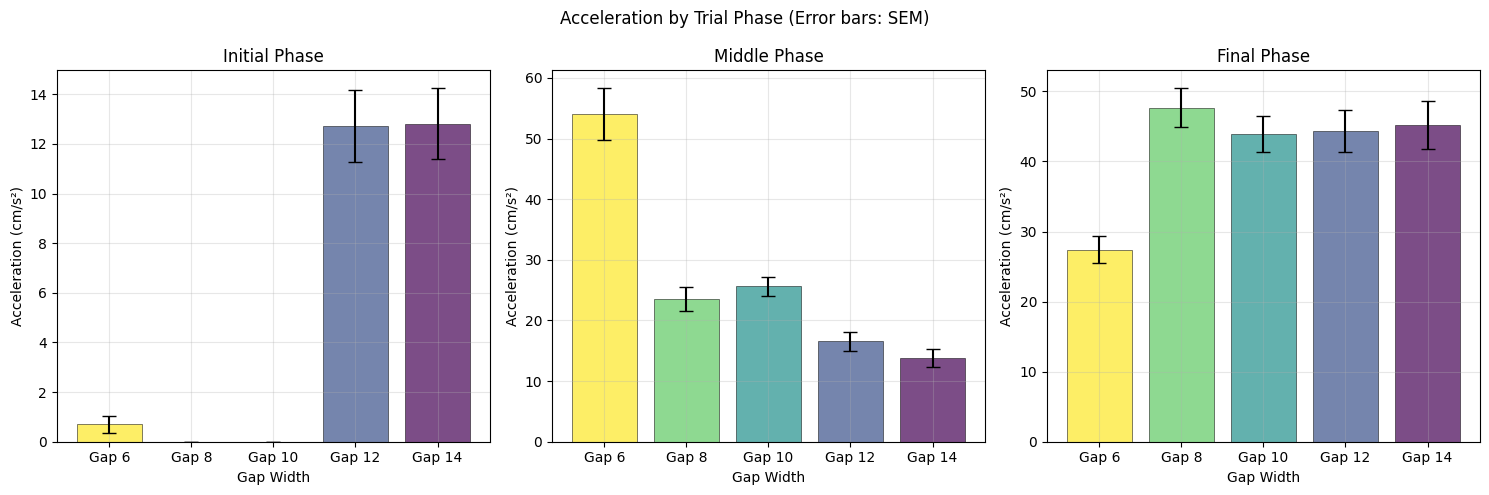

In [9]:
def compute_acceleration(positions_x, positions_y, dt=0.1):
    """Compute acceleration from position data"""
    # Scale to cm: x from [0,59] to [-20,20], y from [0,49] to [-20,20]
    x_cm = (positions_x / 60) * 40 - 20  # maps [0,59] to [-20,20]
    y_cm = (positions_y / 50) * 40 - 20  # maps [0,49] to [-20,20]
    
    # First compute velocity
    dx = np.diff(x_cm)
    dy = np.diff(y_cm)
    velocity_x = dx / dt
    velocity_y = dy / dt
    
    # Then compute acceleration from velocity
    dvx = np.diff(velocity_x)
    dvy = np.diff(velocity_y)
    acceleration = np.sqrt(dvx**2 + dvy**2) / dt
    return acceleration


def analyze_acceleration_multi_gaps(models, envs, info_matrices, gaps, 
                                   trials_per_condition=30, 
                                   colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
                                   save_path=None, 
                                   figure_title='Multi-Gap Acceleration Comparison'):
    """
    Analyze and plot acceleration profiles for multiple models across different gap widths.
    Now uses SEM (Standard Error of the Mean) instead of STD.
    """
    import warnings
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from scipy.stats import sem
    
    gap_percentages = [1, 28, 65, 90, 100]
    # Create figure
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Store acceleration data for all gaps
    all_gap_accelerations = []
    gap_labels = []
    gap_colors = []
    
    # Process each gap/model combination
    for i, (model, env, gap) in enumerate(zip(models, envs, gaps)):
        if model is None:
            print(f"Skipping gap {gap} - model not loaded")
            continue
            
        print(f"Running acceleration analysis for gap width {gap}...")
        
        # Collect trajectory data
        trajectory_data = run_acceleration_trials_improved(model, env, trials_per_condition)
        
        # Process accelerations similar to velocity code style
        left_accelerations = []
        right_accelerations = []
        
        # Process left trials
        for x, y in zip(trajectory_data['left_positions_x'], trajectory_data['left_positions_y']):
            acc = compute_acceleration(x, y)
            if len(acc) > 1:
                progress = np.linspace(0, 1, len(acc))
                common_progress = np.linspace(0, 1, 100)
                interp_acc = np.interp(common_progress, progress, acc)
                left_accelerations.append(interp_acc)
        
        # Process right trials
        for x, y in zip(trajectory_data['right_positions_x'], trajectory_data['right_positions_y']):
            acc = compute_acceleration(x, y)
            if len(acc) > 1:
                progress = np.linspace(0, 1, len(acc))
                common_progress = np.linspace(0, 1, 100)
                interp_acc = np.interp(common_progress, progress, acc)
                right_accelerations.append(interp_acc)
        
        # Combine left and right accelerations
        if left_accelerations and right_accelerations:
            left_acc_array = np.array(left_accelerations)
            right_acc_array = np.array(right_accelerations)
            combined_acc = np.concatenate([left_acc_array, right_acc_array])
            
            # Store for this gap
            all_gap_accelerations.append(combined_acc)
            gap_labels.append(f'{gap_percentages[i]}%')
            gap_colors.append(colors_multi_aperture[i % len(colors_multi_aperture)])
    
    # Plot all gaps
    progress = np.linspace(0, 1, 100)
    
    for i, (accelerations, label, color) in enumerate(zip(all_gap_accelerations, gap_labels, gap_colors)):
        mean_acc = np.mean(accelerations, axis=0)
        sem_acc = sem(accelerations, axis=0)  # Changed from std to sem
        
        # Plot mean line
        plt.plot(progress, mean_acc, color=color, linewidth=2, label=label)
        
        # Plot error band (now using SEM)
        plt.fill_between(progress, 
                        mean_acc - sem_acc, 
                        mean_acc + sem_acc, 
                        alpha=0.3, color=color)
    
    # Styling
    plt.xlabel('Trial progression')
    plt.ylabel('Combined acceleration (cm/s²)')
    plt.title(figure_title)
    plt.legend()
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.3)
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, format='svg', bbox_inches='tight')
    
    plt.show()
    
    # Print acceleration statistics
    print_acceleration_stats_improved(all_gap_accelerations, gaps)


def run_acceleration_trials_improved(model, env, trials_per_condition):
    """Run trials and collect position data for acceleration analysis"""
    import warnings
    import numpy as np
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Storage for position data
        left_trial_positions_x = []
        left_trial_positions_y = []
        right_trial_positions_x = []
        right_trial_positions_y = []
        
        # Run left port trials
        for trial in range(trials_per_condition):
            obs, _ = env.reset(options=0)
            done = False
            positions_x = []
            positions_y = []
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _, info = env.step(action)
                
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
            
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            left_trial_positions_x.append(positions_x)
            left_trial_positions_y.append(positions_y)
        
        # Run right port trials
        for trial in range(trials_per_condition):
            obs, _ = env.reset(options=59)
            done = False
            positions_x = []
            positions_y = []
            
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _, info = env.step(action)
                
                positions_x.append(info['position'][0])
                positions_y.append(info['position'][1])
            
            positions_x = np.array(positions_x)
            positions_y = np.array(positions_y)
            
            right_trial_positions_x.append(positions_x)
            right_trial_positions_y.append(positions_y)
    
    return {
        'left_positions_x': left_trial_positions_x,
        'left_positions_y': left_trial_positions_y,
        'right_positions_x': right_trial_positions_x,
        'right_positions_y': right_trial_positions_y
    }


def print_acceleration_stats_improved(all_gap_accelerations, gaps):
    """Print acceleration statistics for all gaps (now includes SEM)"""
    import numpy as np
    from scipy.stats import sem
    
    print(f"\n=== Multi-Gap Acceleration Statistics ===")
    
    for i, (accelerations, gap) in enumerate(zip(all_gap_accelerations, gaps)):
        # Flatten all acceleration data for this gap
        flat_accelerations = accelerations.flatten()
        
        # Calculate statistics
        mean_acc = np.mean(flat_accelerations)
        std_acc = np.std(flat_accelerations)
        sem_acc = sem(flat_accelerations)  # Added SEM calculation
        max_acc = np.max(flat_accelerations)
        min_acc = np.min(flat_accelerations)
        
        print(f"Gap {gap}:")
        print(f"  Mean acceleration: {mean_acc:.2f} ± {sem_acc:.2f} cm/s² (SEM)")
        print(f"  Standard deviation: {std_acc:.2f} cm/s²")
        print(f"  Max acceleration: {max_acc:.2f} cm/s²")
        print(f"  Min acceleration: {min_acc:.2f} cm/s²")
        print()


def analyze_acceleration_by_phase_multi_gaps_improved(models, envs, info_matrices, gaps, 
                                                     trials_per_condition=30, 
                                                     colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
                                                     save_path=None):
    """
    Analyze acceleration in different phases: initial, middle, final thirds of trajectory
    Now uses SEM instead of STD for error bars.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import sem
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    phases = ['Initial', 'Middle', 'Final']
    axes = [ax1, ax2, ax3]
    
    gap_phase_data = {}
    
    for i, (model, env, gap) in enumerate(zip(models, envs, gaps)):
        if model is None:
            continue
            
        print(f"Running acceleration phase analysis for gap width {gap}...")
        
        # Collect trajectory data
        trajectory_data = run_acceleration_trials_improved(model, env, trials_per_condition)
        
        # Combine left and right positions
        all_positions_x = trajectory_data['left_positions_x'] + trajectory_data['right_positions_x']
        all_positions_y = trajectory_data['left_positions_y'] + trajectory_data['right_positions_y']
        
        # Analyze acceleration in three phases
        phase_accelerations = [[], [], []]  # initial, middle, final
        
        for x, y in zip(all_positions_x, all_positions_y):
            acc = compute_acceleration(x, y)
            if len(acc) >= 3:
                third = len(acc) // 3
                phase_accelerations[0].extend(acc[:third])           # Initial
                phase_accelerations[1].extend(acc[third:2*third])   # Middle  
                phase_accelerations[2].extend(acc[2*third:])        # Final
        
        gap_phase_data[gap] = phase_accelerations
    
    # Plot phase comparisons
    for phase_idx, (ax, phase_name) in enumerate(zip(axes, phases)):
        gap_means = []
        gap_sems = []  # Changed from gap_stds to gap_sems
        gap_labels = []
        gap_colors = []
        
        for i, gap in enumerate(gaps):
            if gap in gap_phase_data and gap_phase_data[gap][phase_idx]:
                phase_acc = np.array(gap_phase_data[gap][phase_idx])
                gap_means.append(np.mean(phase_acc))
                gap_sems.append(sem(phase_acc))  # Changed from std to sem
                gap_labels.append(f'Gap {gap}')
                gap_colors.append(colors_multi_aperture[i % len(colors_multi_aperture)])
        
        # Bar plot with error bars (now using SEM)
        x_pos = np.arange(len(gap_labels))
        bars = ax.bar(x_pos, gap_means, yerr=gap_sems, capsize=5, 
                     color=gap_colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        
        ax.set_xlabel('Gap Width')
        ax.set_ylabel('Acceleration (cm/s²)')
        ax.set_title(f'{phase_name} Phase')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(gap_labels)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Acceleration by Trial Phase (Error bars: SEM)')
    plt.tight_layout()
    
    if save_path:
        phase_save_path = save_path.replace('.svg', '_phases.svg')
        plt.savefig(phase_save_path, format='svg', bbox_inches='tight')
    
    plt.show()


def analyze_acceleration_magnitude_distribution(models, envs, info_matrices, gaps, 
                                               trials_per_condition=30, 
                                               colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
                                               save_path=None):
    """
    Plot distribution of acceleration magnitudes for each gap condition
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for i, (model, env, gap) in enumerate(zip(models, envs, gaps)):
        if model is None:
            continue
            
        print(f"Computing acceleration distribution for gap width {gap}...")
        
        # Collect trajectory data
        trajectory_data = run_acceleration_trials_improved(model, env, trials_per_condition)
        
        # Combine all positions
        all_positions_x = trajectory_data['left_positions_x'] + trajectory_data['right_positions_x']
        all_positions_y = trajectory_data['left_positions_y'] + trajectory_data['right_positions_y']
        
        # Compute all accelerations
        all_accelerations = []
        for x, y in zip(all_positions_x, all_positions_y):
            acc = compute_acceleration(x, y)
            all_accelerations.extend(acc)
        
        # Plot histogram
        color = colors_multi_aperture[i % len(colors_multi_aperture)]
        plt.hist(all_accelerations, bins=50, alpha=0.6, label=f'Gap {gap}', 
                color=color, density=True)
    
    plt.xlabel('Acceleration (cm/s²)')
    plt.ylabel('Density')
    plt.title('Acceleration Magnitude Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        dist_save_path = save_path.replace('.svg', '_distribution.svg')
        plt.savefig(dist_save_path, format='svg', bbox_inches='tight')
    
    plt.show()


# Usage example:
"""
# Run acceleration analysis
analyze_acceleration_multi_gaps(
    models=models,
    envs=envs, 
    info_matrices=info_matrices,
    gaps=gaps,
    trials_per_condition=30,
    colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
    save_path="acceleration_comparison.svg",
    figure_title="Multi-Gap Acceleration Profiles"
)

# Run phase-based acceleration analysis
analyze_acceleration_by_phase_multi_gaps_improved(
    models=models,
    envs=envs, 
    info_matrices=info_matrices,
    gaps=gaps,
    trials_per_condition=30,
    colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
    save_path="acceleration_phases.svg"
)

# Run acceleration distribution analysis
analyze_acceleration_magnitude_distribution(
    models=models,
    envs=envs, 
    info_matrices=info_matrices,
    gaps=gaps,
    trials_per_condition=30,
    colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
    save_path="acceleration_distribution.svg"
)
"""

analyze_acceleration_multi_gaps(
    models=models,
    envs=envs, 
    info_matrices=info_matrices,
    gaps=gaps,
    trials_per_condition=30,
    colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
    save_path="acceleration_comparison.svg",
    figure_title="Multi-Gap Acceleration Profiles"
)

analyze_acceleration_by_phase_multi_gaps_improved(
    models=models,
    envs=envs, 
    info_matrices=info_matrices,
    gaps=gaps,
    trials_per_condition=30,
    colors_multi_aperture=["#fde725", "#5ec962", "#21918c", "#3b528b", "#440154"],
    save_path="acceleration_phases.svg"
)